In [1]:
# imports

import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import numpy as np
from scipy.signal import savgol_filter
import scipy.stats as stats


# Configuração do diretório
data_dir = r"C:\Users\gabri\Documents\PROJETOS\POLI\Lab Física\Fotoelétrico\Quim\Eng Quimica - Grupo 2 - Fotoeletrico"
sem_file = os.path.join(data_dir, "1 CORRENTE DE ESCURO.csv")

# Carregar dados de ruído (fundo)
df_sem = pd.read_csv(sem_file, sep=";", decimal=",")

In [2]:
# Dados

# Frequências
frequencias = {
    "Vermelho": 4.875,
    "Amarelo": 5.187,  # Média das linhas do dubleto (5.196 e 5.178)
    "Verde": 5.490,
    "Azul": 6.879,
    "Violeta": 7.409,
    "Ultra-Violeta": 8.213,
}

In [3]:
# Ordem e cores

# Ordem: Amarelo, Verde, Azul, Violeta, Ultra-Violeta, Vermelho
colors_info = [
    {
        "name": "Amarelo",
        "prefix": "AMARELO",
        "letter": "(a)",
        "xlim": (-1.5, 0.5),
        "ylim": (-1.5, 1.5),
    },
    {
        "name": "Verde",
        "prefix": "VERDE",
        "letter": "(b)",
        "xlim": (-2.5, 0.5),
        "ylim": (-1.5, 1.5),
    },
    {
        "name": "Azul",
        "prefix": "AZUL",
        "letter": "(c)",
        "xlim": (-3.0, 0.5),
        "ylim": (-1.5, 1.5),
    },
    {
        "name": "Violeta",
        "prefix": "VIOLETA",
        "letter": "(d)",
        "xlim": (-3.5, 0.5),
        "ylim": (-1.5, 1.5),
    },
    {
        "name": "Ultra-Violeta",
        "prefix": "UV",
        "letter": "(e)",
        "xlim": (-4.0, 0.5),
        "ylim": (-1.5, 1.5),
    },
    {
        "name": "Vermelho",
        "prefix": "VERMELHO",
        "letter": "(f)",
        "xlim": (-1.5, 1.0),
        "ylim": (-1.5, 1.5),
    },
]

# Intensidades cores
intensity_colors = {
    100: "tab:green",
    80: "#f9d71c",
    60: "tab:blue",
    40: "tab:red",
    20: "tab:gray",
}

intensities = [100, 80, 60, 40, 20]

# Estilo global dos gráficos
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["axes.axisbelow"] = True

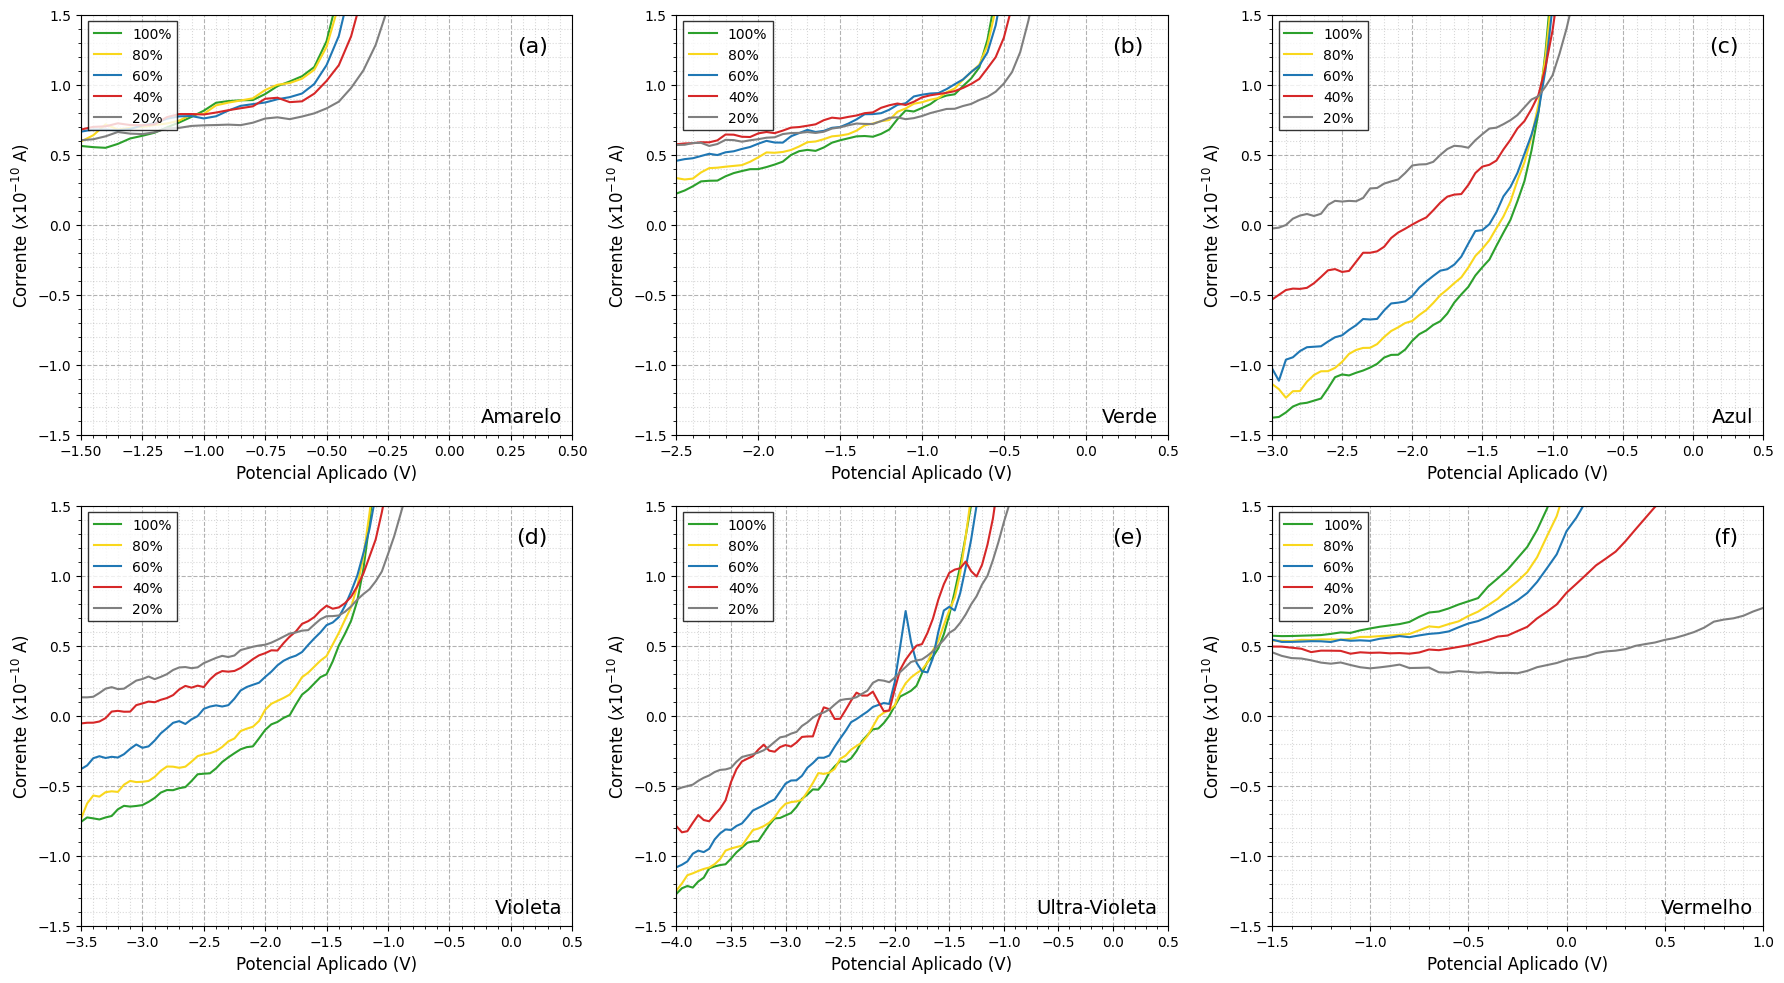

In [4]:
# Gráficos das medições

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, info in enumerate(colors_info):
    ax = axes_flat[i]

    # Ordenar intensidades para legenda (descendente conforme imagem)
    intensities_to_plot = [100, 80, 60, 40, 20]

    for intensity in intensities_to_plot:
        file_path = os.path.join(data_dir, f"{info['prefix']} {intensity}.csv")

        if os.path.exists(file_path):
            df = pd.read_csv(file_path, sep=";", decimal=",")

            corrente = df["Corrente [A]"]
            if df_sem is not None and len(df) == len(df_sem):
                corrente = corrente - df_sem["Corrente [A]"]

            corrente_plot = corrente * 1e10
            tensao = df["Tensao [V]"]

            ax.plot(
                tensao,
                corrente_plot,
                label=f"{intensity}%",
                color=intensity_colors.get(intensity, "black"),
                linewidth=1.5,
            )

    # Configurações estéticas por subplot
    ax.set_xlabel("Potencial Aplicado (V)", fontsize=12)
    ax.set_ylabel(r"Corrente ($x10^{-10}$ A)", fontsize=12)

    # Letra (a, b, c...) no topo direito
    ax.text(
        0.95,
        0.95,
        info["letter"],
        transform=ax.transAxes,
        fontsize=16,
        va="top",
        ha="right",
    )

    # Nome da cor no canto inferior direito
    ax.text(
        0.98,
        0.02,
        info["name"],
        transform=ax.transAxes,
        fontsize=14,
        va="bottom",
        ha="right",
    )

    # Grid e ticks
    ax.grid(True, which="major", linestyle="--", color="gray", alpha=0.6)
    ax.minorticks_on()
    ax.grid(True, which="minor", linestyle=":", color="gray", alpha=0.3)

    # Legenda
    ax.legend(
        loc="upper left", fontsize=10, frameon=True, edgecolor="black", fancybox=False
    )

    # Limites de escala
    if info["xlim"]:
        ax.set_xlim(info["xlim"])
    if info["ylim"]:
        ax.set_ylim(info["ylim"])

    ax.tick_params(axis="both", which="major", labelsize=10)

plt.tight_layout()
plt.show()

In [5]:
# Funções para os 4 Métodos de determinação de V0
import itertools

# Escala para evitar problemas de precisão e thresholds com valores de 1e-10
SCALE = 1e10


def method_1_zero_crossing(v, i_vals):
    """
    Método 1: Identificar o V0 (Cruzamento com zero).
    """
    # Usar dados em escala para suavizar
    i_s = i_vals * SCALE
    signs = np.sign(i_s)
    sign_changes = ((np.roll(signs, 1) - signs) != 0).astype(int)
    sign_changes[0] = 0
    indices = np.where(sign_changes == 1)[0]

    best_v0 = np.nan
    for idx in indices:
        if idx == 0 or idx >= len(v):
            continue
        y0, y1 = i_s[idx - 1], i_s[idx]
        x0, x1 = v[idx - 1], v[idx]
        if abs(y1 - y0) < 1e-15:
            continue
        v_cross = x0 - y0 * (x1 - x0) / (y1 - y0)
        best_v0 = v_cross
    return best_v0


def method_2_tangents(v, i_vals):
    """
    Método 2: Intersecção das retas assintóticas.
    """
    i_s = i_vals * SCALE
    i_smooth = savgol_filter(i_s, 15, 3)
    di = np.gradient(i_smooth)
    max_deriv_idx = np.argmax(di)

    window = 10
    s_r, e_r = max(0, max_deriv_idx - window), min(len(v), max_deriv_idx + window)
    if s_r >= e_r:
        return np.nan

    res_rise = stats.linregress(v[s_r:e_r], i_smooth[s_r:e_r])

    # Fundo: Região à esquerda (V < V0) onde a corrente deve ser zero
    e_b = max(5, s_r - 10)
    s_b = max(0, e_b - 40)
    res_bg = stats.linregress(v[s_b:e_b], i_smooth[s_b:e_b])

    if abs(res_rise.slope - res_bg.slope) < 1e-5:
        return np.nan
    return (res_bg.intercept - res_rise.intercept) / (res_rise.slope - res_bg.slope)


def method_3_intersection_curves(curves_list):
    """
    Método 3: Intersecção das curvas de diferentes intensidades.
    Como físico, este método busca o ponto onde a variação da intensidade não altera a corrente (teoricamente I=0).
    Ajustamos a reta de subida para cada intensidade e calculamos suas intersecções mútuas.
    """
    if len(curves_list) < 2:
        return np.nan

    lines = []
    for v, i_vals in curves_list:
        i_s = i_vals * SCALE
        i_smooth = savgol_filter(i_s, 15, 3)
        di = np.gradient(i_smooth)
        max_idx = np.argmax(di)

        # Seleciona a zona linear de subida
        w = 8
        s, e = max(0, max_idx - w), min(len(v), max_idx + w)
        if s < e:
            res = stats.linregress(v[s:e], i_smooth[s:e])
            lines.append((res.slope, res.intercept))

    if len(lines) < 2:
        return np.nan

    v0_candidates = []
    for (a1, b1), (a2, b2) in itertools.combinations(lines, 2):
        # Threshold ajustado para a escala 1e10.
        # Diferentes intensidades DEVEM ter inclinações diferentes.
        if abs(a1 - a2) > 1e-2:
            v_int = (b2 - b1) / (a1 - a2)
            # Filtro físico: V0 deve estar no range de medição
            if -5 < v_int < 1:
                v0_candidates.append(v_int)

    return np.median(v0_candidates) if v0_candidates else np.nan


def method_4_second_derivative(v, i_vals):
    """
    Método 4: Análise da segunda derivada (Ponto de máxima curvatura).
    """
    i_s = i_vals * SCALE
    i_smooth = savgol_filter(i_s, 31, 3)
    di = np.gradient(i_smooth, v)
    d2i = np.gradient(di, v)
    return v[np.argmax(np.abs(d2i))]


# --- Execução da Análise ---

resultados_list = []
print(
    f"{'Cor':<15} | {'M1: Zero':<10} | {'M2: Tan':<10} | {'M3: Inter':<10} | {'M4: 2Der':<10}"
)
print("-" * 65)

for info in colors_info:
    cor_name = info["name"]
    prefix = info["prefix"]

    curves_data = []
    v_main, i_main = None, None

    # Coleta todas as intensidades disponíveis
    for intensity in [100, 80, 60, 40, 20]:
        fpath = os.path.join(data_dir, f"{prefix} {intensity}.csv")
        if os.path.exists(fpath):
            df_temp = pd.read_csv(fpath, sep=";", decimal=",")
            corrente = df_temp["Corrente [A]"].values
            if df_sem is not None and len(corrente) == len(df_sem):
                corrente = corrente - df_sem["Corrente [A]"].values
            tensao = df_temp["Tensao [V]"].values

            curves_data.append((tensao, corrente))
            if intensity == 100 or v_main is None:
                v_main, i_main = tensao, corrente

    if v_main is not None:
        v0_m1 = method_1_zero_crossing(v_main, i_main)
        v0_m2 = method_2_tangents(v_main, i_main)
        v0_m3 = method_3_intersection_curves(curves_data)
        v0_m4 = method_4_second_derivative(v_main, i_main)

        # Escolha do melhor V0 para a regressão de Planck (M2 costuma ser o padrão acadêmico)
        v0_final = v0_m2 if not np.isnan(v0_m2) else v0_m1

        resultados_list.append(
            {
                "Cor": cor_name,
                "V0_M1": v0_m1,
                "V0_M2": v0_m2,
                "V0_M3": v0_m3,
                "V0_M4": v0_m4,
                "V0_medio": v0_final,
                "Incerteza": 0.05,
            }
        )
        print(
            f"{cor_name:<15} | {v0_m1:8.4f} | {v0_m2:8.4f} | {v0_m3:8.4f} | {v0_m4:8.4f}"
        )

df_resultados = pd.DataFrame(resultados_list)

Cor             | M1: Zero   | M2: Tan    | M3: Inter  | M4: 2Der  
-----------------------------------------------------------------
Amarelo         |      nan |  -0.2102 |  -0.2048 |  -0.1500
Verde           |  -4.0224 |  -0.2742 |  -0.2651 |  -0.3000
Azul            |  -1.3184 |  -0.4281 |  -0.4226 |  -0.3000
Violeta         |  -1.8085 |  -0.3494 |  -0.4158 |  -0.3000
Ultra-Violeta   |  -2.0489 |  -0.4012 |  -0.4622 |  -0.2000
Vermelho        |      nan |  -0.1487 |  -0.2654 |  -0.2000


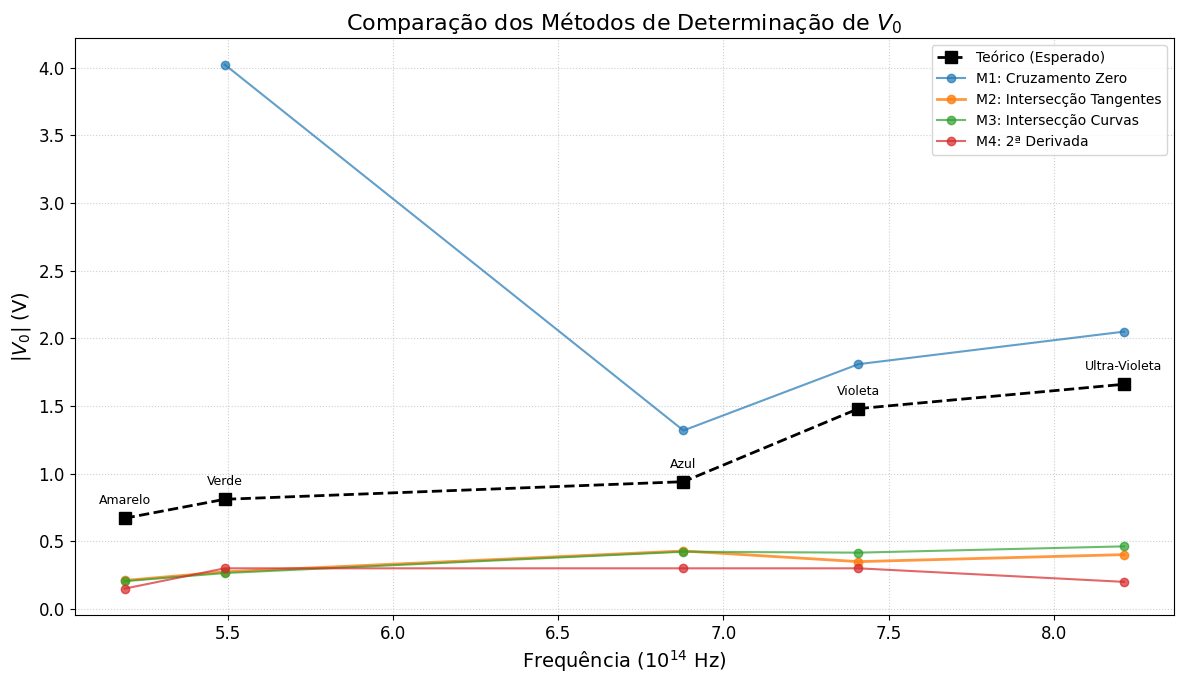


--- Erro Relativo (%) em relação ao Esperado ---
          Cor  Erro_V0_M1(%)  Erro_V0_M2(%)  Erro_V0_M3(%)  Erro_V0_M4(%)
      Amarelo            NaN          68.63          69.44          77.61
        Verde         396.59          66.15          67.28          62.96
         Azul          40.26          54.46          55.04          68.09
      Violeta          22.20          76.39          71.91          79.73
Ultra-Violeta          23.43          75.83          72.16          87.95

--- Erro Médio (%) por Método ---
V0_M1: 120.62%
V0_M2: 68.29%
V0_M3: 67.16%
V0_M4: 75.27%


In [6]:
# Comparação com Valores Esperados e Gráfico de Desempenho dos Métodos

# Dados teóricos/esperados fornecidos
expected_data = {
    "Ultra-Violeta": 1.66,
    "Violeta": 1.48,
    "Azul": 0.94,
    "Verde": 0.81,
    "Amarelo": 0.67,
}

# Preparar DataFrame de comparação (aplicando módulo)
df_comp = df_resultados.copy()
metodos = ["V0_M1", "V0_M2", "V0_M3", "V0_M4"]

for m in metodos:
    df_comp[m] = df_comp[m].abs()

df_comp["Esperado"] = df_comp["Cor"].map(expected_data)
df_comp["f"] = df_comp["Cor"].map(frequencias)

# Ordenar por frequência para o gráfico de linhas
df_comp = df_comp.dropna(subset=["Esperado"]).sort_values("f")

# Plotagem da Comparação
plt.figure(figsize=(12, 7))

# Plotar cada método
plt.plot(
    df_comp["f"],
    df_comp["Esperado"],
    "k--",
    marker="s",
    label="Teórico (Esperado)",
    linewidth=2,
    markersize=8,
)
plt.plot(df_comp["f"], df_comp["V0_M1"], "o-", label="M1: Cruzamento Zero", alpha=0.7)
plt.plot(
    df_comp["f"],
    df_comp["V0_M2"],
    "o-",
    label="M2: Intersecção Tangentes",
    alpha=0.8,
    linewidth=2,
)
plt.plot(
    df_comp["f"], df_comp["V0_M3"], "o-", label="M3: Intersecção Curvas", alpha=0.7
)
plt.plot(df_comp["f"], df_comp["V0_M4"], "o-", label="M4: 2ª Derivada", alpha=0.7)

# Estética do gráfico
plt.title("Comparação dos Métodos de Determinação de $V_0$", fontsize=16)
plt.xlabel("Frequência ($10^{14}$ Hz)", fontsize=14)
plt.ylabel("$|V_0|$ (V)", fontsize=14)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)

# Incluir anotação das cores no eixo X ou pontos
for i, row in df_comp.iterrows():
    plt.annotate(
        row["Cor"],
        (row["f"], row["Esperado"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# Exibir tabela de erros relativos (%)
for m in metodos:
    df_comp[f"Erro_{m}(%)"] = (
        np.abs((df_comp[m] - df_comp["Esperado"]) / df_comp["Esperado"]) * 100
    )

df_resultados = pd.DataFrame(resultados_list)

print("\n--- Erro Relativo (%) em relação ao Esperado ---")
columns_show = ["Cor"] + [f"Erro_{m}(%)" for m in metodos]
print(df_comp[columns_show].to_string(index=False, float_format="{:.2f}".format))

# Calcular e exibir erro médio de cada método
print("\n--- Erro Médio (%) por Método ---")
for m in metodos:
    erro_medio = df_comp[f"Erro_{m}(%)"].mean()
    print(f"{m}: {erro_medio:.2f}%")

Gráfico: Método da Tangente


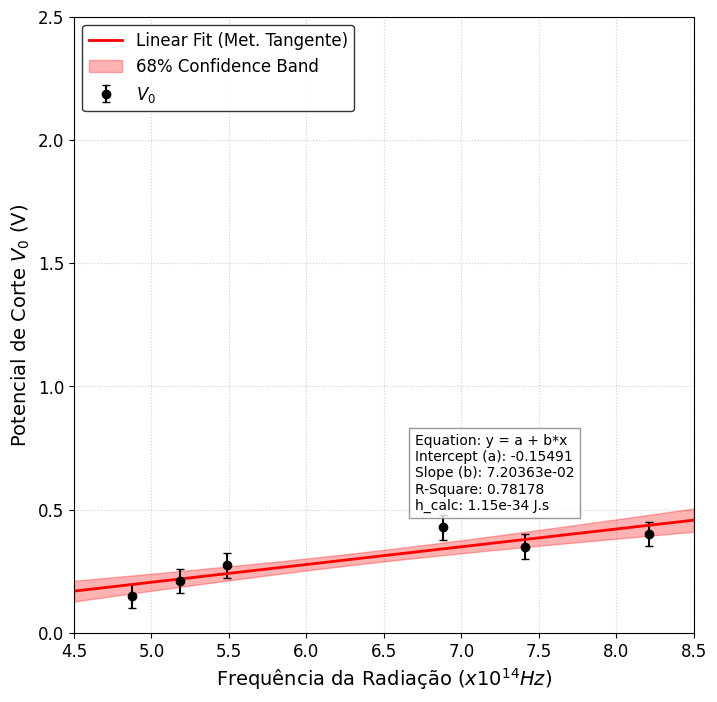

In [7]:
# Curva de V0 x f


def plot_planck_graph(df_res, title_suffix=""):
    # Preparar dados: converter V0 para valor absoluto (magnitude)
    df_plot = df_res.copy()
    df_plot["f"] = df_plot["Cor"].map(frequencias)
    df_plot["V0_abs"] = np.abs(df_plot["V0_medio"])  # Converter para módulo

    # Remover falhas
    df_plot = df_plot.dropna(subset=["f", "V0_abs"])
    x = df_plot["f"].values
    y = df_plot["V0_abs"].values
    y_err = df_plot["Incerteza"].values

    # Ajuste Linear
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    line = slope * x + intercept

    # Cálculo da Banda de Confiança (68% -> 1 sigma)
    # Aproximação simples para o erro da predição
    n = len(x)
    x_grid = np.linspace(4.5, 8.5, 100)
    y_grid = slope * x_grid + intercept

    # Erro residual
    resid = y - (slope * x + intercept)
    s_err = np.sqrt(np.sum(resid**2) / (n - 2))

    conf_band = s_err * np.sqrt(
        1 / n + (x_grid - np.mean(x)) ** 2 / np.sum((x - np.mean(x)) ** 2)
    )

    # Plotagem
    fig, ax = plt.subplots(figsize=(8, 8))

    # Pontos e Erro
    ax.errorbar(x, y, yerr=y_err, fmt="ok", capsize=3, label=r"$V_0$")

    # Linha e Banda
    ax.plot(x_grid, y_grid, "r-", linewidth=2, label=f"Linear Fit {title_suffix}")
    ax.fill_between(
        x_grid,
        y_grid - conf_band,
        y_grid + conf_band,
        color="red",
        alpha=0.3,
        label="68% Confidence Band",
    )

    # Estética
    ax.set_xlabel(r"Frequência da Radiação ($x10^{14} Hz$)", fontsize=14)
    ax.set_ylabel(r"Potencial de Corte $V_0$ (V)", fontsize=14)
    ax.set_xlim(4.5, 8.5)
    ax.set_ylim(0, 2.5)

    # Tabela de Resultados (Ajuste conforme imagem)
    stats_text = (
        f"Equation: y = a + b*x\n"
        f"Intercept (a): {intercept:.5f}\n"
        f"Slope (b): {slope:.5e}\n"
        f"R-Square: {r_value**2:.5f}\n"
        f"h_calc: {slope * 1.602e-19 * 1e-14:.2e} J.s"
    )
    ax.text(
        0.55,
        0.2,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray"),
    )

    ax.legend(loc="upper left", frameon=True, edgecolor="black")
    ax.grid(True, linestyle=":", alpha=0.6)
    plt.show()


# Gerar para ambos os métodos (supondo que você salvou os dataframes)
print("Gráfico: Método da Tangente")
plot_planck_graph(df_resultados, "(Met. Tangente)")